# Import des librairies

In [2]:
import matplotlib.pyplot as plt
from itertools import islice
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import clear_output, display
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import os
from torch.utils.data import ConcatDataset
from NN import PyTorchMLPDropout, PyTorchMLPDropConnect
from IPython.display import clear_output, display

# Demo on MNIST

## Loading the dataset

Loading MNIST:   0%|          | 0/10 [00:00<?, ?it/s]

Loading Fashion-MNIST:   0%|          | 0/10 [00:00<?, ?it/s]

MNIST (train, test) : 60000, 10000
Fashion-MNIST (train, test) : 60000, 10000
Examples of MNIST and Fashion-MNIST images:


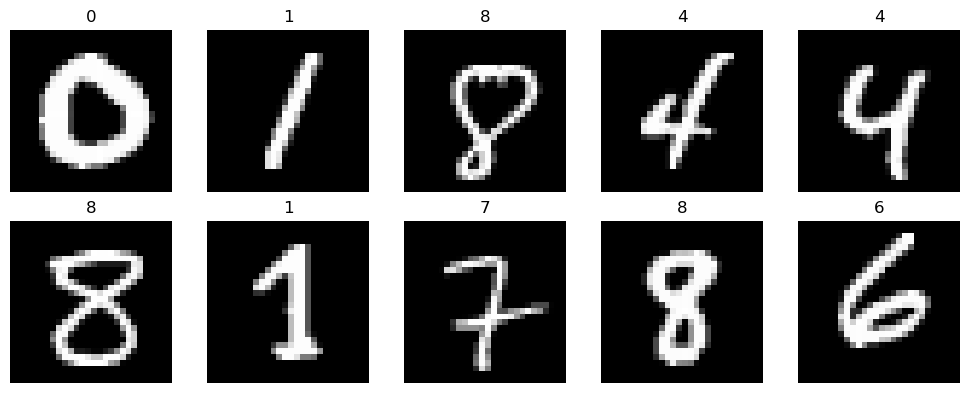

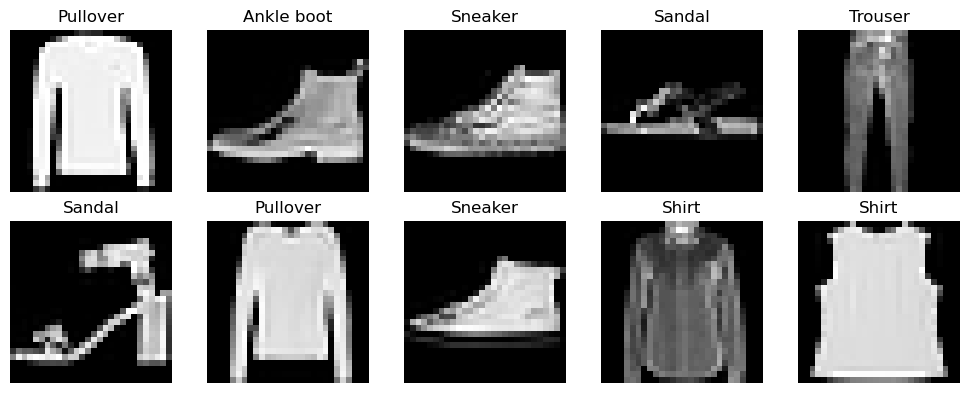

In [3]:
data_root = "./dataset"
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

fashion_train = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)
fashion_test = datasets.FashionMNIST(root=data_root, train=False, download=True, transform=transform)

mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

fashion_train_loader = DataLoader(fashion_train, batch_size=batch_size, shuffle=True)
fashion_test_loader = DataLoader(fashion_test, batch_size=batch_size, shuffle=False)

# Loading bar
for _ in tqdm(islice(mnist_train_loader, 10), total=10, desc="Loading MNIST"):
    pass
for _ in tqdm(islice(fashion_train_loader, 10), total=10, desc="Loading Fashion-MNIST"):
    pass

print(f"MNIST (train, test) : {len(mnist_train)}, {len(mnist_test)}\nFashion-MNIST (train, test) : {len(fashion_train)}, {len(fashion_test)}")

print("Examples of MNIST and Fashion-MNIST images:")

# Display 10 random MNIST images with their labels
if "mnist_train" not in globals():
    data_root = "./dataset"
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    mnist_train = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)

idx = np.random.choice(len(mnist_train), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for ax, i in zip(axes, idx):
    img, label = mnist_train[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")

plt.tight_layout()
plt.show()

# Display 10 random Fashion-MNIST images with their labels
if "fashion_train" not in globals():
    data_root = "./dataset"
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    fashion_train = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)

fashion_classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
 ]

idx = np.random.choice(len(fashion_train), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for ax, i in zip(axes, idx):
    img, label = fashion_train[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(fashion_classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Training our models

### Supervised Learning : Multi-Layer Perceptron

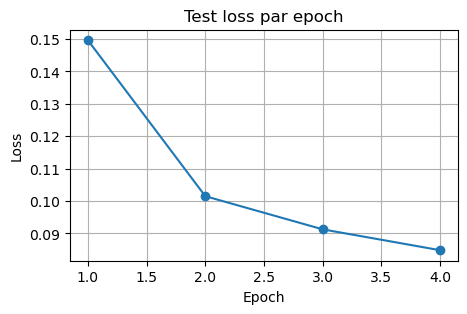

MLP_MNIST(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLP_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        return self.net(x)

mlp_mnist = MLP_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_mnist.parameters(), lr=1e-3)

epochs = 4
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    mlp_mnist.train()
    running_loss = 0.0
    for x, y in tqdm(mnist_train_loader, desc=f"Epoch {epoch}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = mlp_mnist(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    mlp_mnist.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for x, y in mnist_test_loader:
            x, y = x.to(device), y.to(device)
            logits = mlp_mnist(x)
            loss = criterion(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    acc = correct / total
    print(f"Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f} - acc: {acc:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("Test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(mlp_mnist)

### Supervised Learning : Convolutional Neural Network

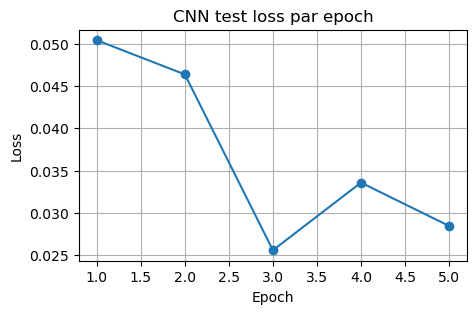

CNN_MNIST(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class CNN_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_mnist = CNN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_mnist.parameters(), lr=1e-3)

epochs = 5
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    cnn_mnist.train()
    running_loss = 0.0
    for x, y in tqdm(mnist_train_loader, desc=f"CNN Epoch {epoch}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = cnn_mnist(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    cnn_mnist.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for x, y in mnist_test_loader:
            x, y = x.to(device), y.to(device)
            logits = cnn_mnist(x)
            loss = criterion(logits, y)
            test_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    acc = correct / total
    print(f"CNN Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f} - acc: {acc:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("CNN test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(cnn_mnist)

### Unsupervised Learning : MLP Auto-Encoder

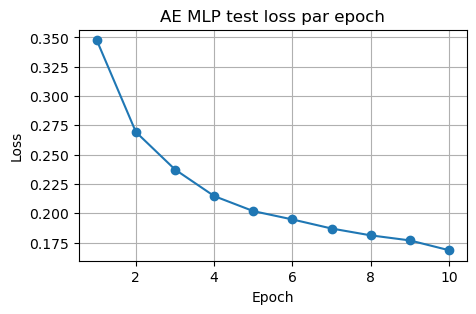

AE_MLP_MNIST(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=784, bias=True)
  )
)


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_MLP_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 28 * 28)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

ae_mlp_mnist = AE_MLP_MNIST().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_mlp_mnist.parameters(), lr=1e-3)

epochs = 10
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_mlp_mnist.train()
    running_loss = 0.0
    for x, _ in tqdm(mnist_train_loader, desc=f"AE Epoch {epoch}"):
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        optimizer.zero_grad()
        recon = ae_mlp_mnist(x_flat)
        loss = criterion(recon, x_flat)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    ae_mlp_mnist.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in mnist_test_loader:
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)
            recon = ae_mlp_mnist(x_flat)
            loss = criterion(recon, x_flat)
            test_loss += loss.item() * x.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    print(f"AE Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("AE MLP test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_mlp_mnist)

### Unsupervised Learning : CNN Auto-Encoder

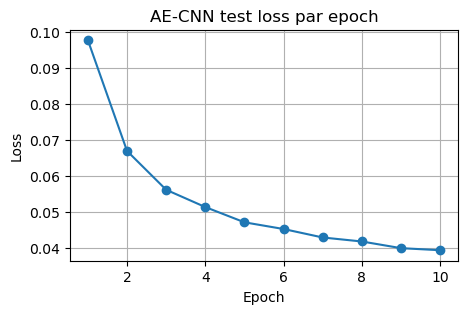

AE_CNN_MNIST(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=32, bias=True)
  )
  (unbottleneck): Sequential(
    (0): Linear(in_features=32, out_features=6272, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_CNN_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.bottleneck = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 32)
        )
        self.unbottleneck = nn.Sequential(
            nn.Linear(32, 128 * 7 * 7),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        z = self.bottleneck(x)
        x = self.unbottleneck(z).view(-1, 128, 7, 7)
        x = self.decoder(x)
        return x

ae_cnn_mnist = AE_CNN_MNIST().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_cnn_mnist.parameters(), lr=1e-3)

epochs = 10
test_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_cnn_mnist.train()
    running_loss = 0.0
    for x, _ in tqdm(mnist_train_loader, desc=f"AE-CNN Epoch {epoch}"):
        x = x.to(device)
        optimizer.zero_grad()
        recon = ae_cnn_mnist(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(mnist_train_loader.dataset)

    ae_cnn_mnist.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in mnist_test_loader:
            x = x.to(device)
            recon = ae_cnn_mnist(x)
            loss = criterion(recon, x)
            test_loss += loss.item() * x.size(0)
    test_loss = test_loss / len(mnist_test_loader.dataset)
    test_losses.append(test_loss)
    print(f"AE-CNN Epoch {epoch} - loss: {train_loss:.4f} - val_loss: {test_loss:.4f}")

    # Actualisation du même graphe (taille fixe)
    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(test_losses) + 1), test_losses, marker="o")
    ax.set_title("AE-CNN test loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_cnn_mnist)

### Model performance comparaison

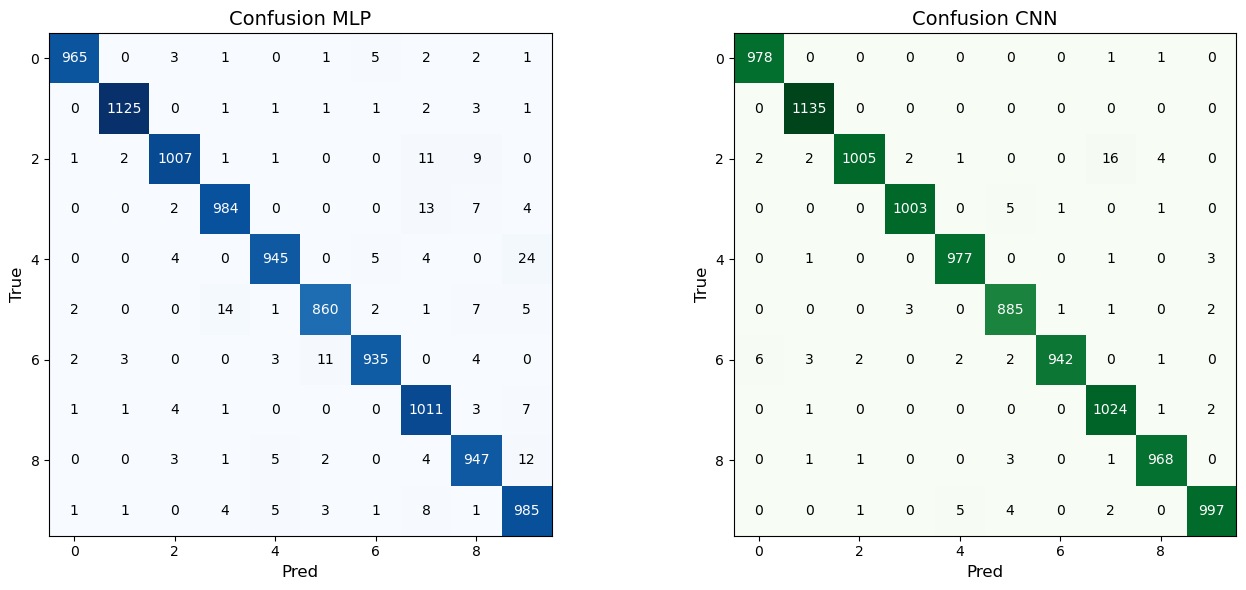

,model,accuracy,precision_macro,recall_macro,f1_macro
0,MLP,0.9764,0.976502,0.976031,0.976203
1,CNN,0.9914,0.991395,0.991328,0.991331


In [9]:
# Comparaison MLP vs CNN sur le test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_mnist.eval()
cnn_mnist.eval()

y_true = []
y_pred_mlp = []
y_pred_cnn = []

with torch.no_grad():
    for x, y in mnist_test_loader:
        x = x.to(device)
        logits_mlp = mlp_mnist(x)
        logits_cnn = cnn_mnist(x)
        y_true.extend(y.numpy().tolist())
        y_pred_mlp.extend(logits_mlp.argmax(dim=1).cpu().numpy().tolist())
        y_pred_cnn.extend(logits_cnn.argmax(dim=1).cpu().numpy().tolist())

cm_mlp = confusion_matrix(y_true, y_pred_mlp)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cm_mlp, cmap="Blues")
axes[0].set_title("Confusion MLP", fontsize=14)
axes[0].set_xlabel("Pred", fontsize=12)
axes[0].set_ylabel("True", fontsize=12)
axes[1].imshow(cm_cnn, cmap="Greens")
axes[1].set_title("Confusion CNN", fontsize=14)
axes[1].set_xlabel("Pred", fontsize=12)
axes[1].set_ylabel("True", fontsize=12)

# Afficher les valeurs dans chaque case
for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        axes[0].text(j, i, cm_mlp[i, j], ha="center", va="center", fontsize=10,
                     color="white" if cm_mlp[i, j] > cm_mlp.max() / 2 else "black")
for i in range(cm_cnn.shape[0]):
    for j in range(cm_cnn.shape[1]):
        axes[1].text(j, i, cm_cnn[i, j], ha="center", va="center", fontsize=10,
                     color="white" if cm_cnn[i, j] > cm_cnn.max() / 2 else "black")

plt.tight_layout()
plt.show()

metrics = pd.DataFrame([
    {
        "model": "MLP",
        "accuracy": accuracy_score(y_true, y_pred_mlp),
        "precision_macro": precision_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_mlp, average="macro", zero_division=0),
    },
    {
        "model": "CNN",
        "accuracy": accuracy_score(y_true, y_pred_cnn),
        "precision_macro": precision_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_cnn, average="macro", zero_division=0),
    }
])

metrics

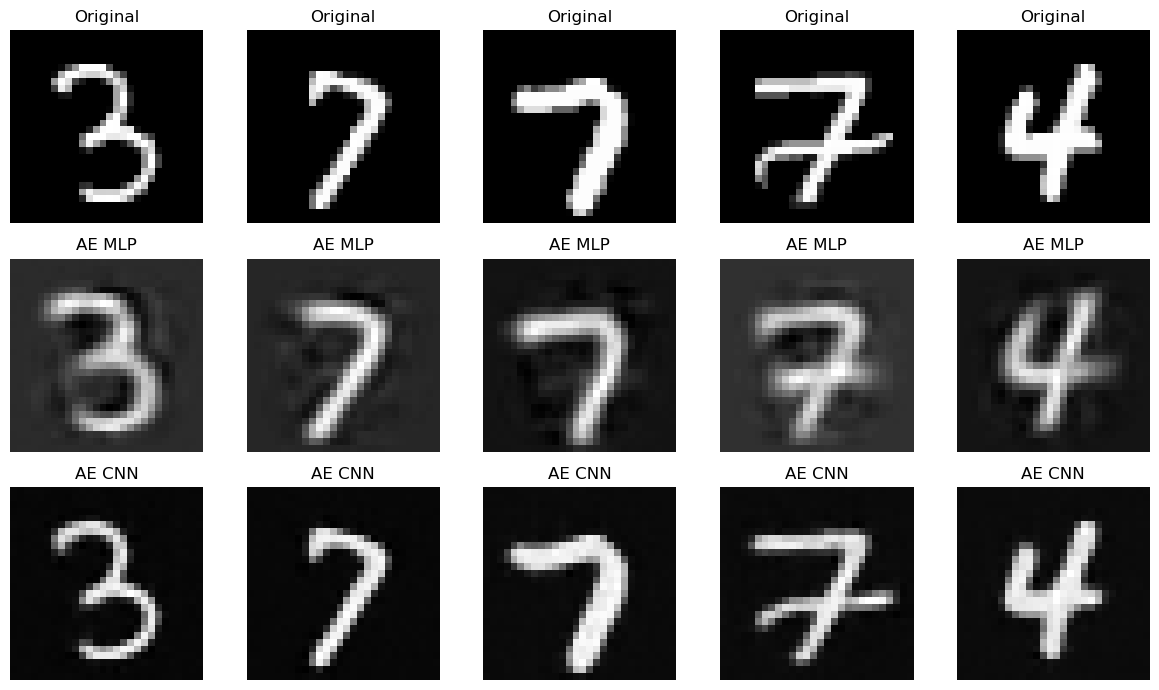

In [10]:
# Comparer les reconstructions des auto-encodeurs (5 images test)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ae_mlp_mnist.eval()
ae_cnn_mnist.eval()

idx = np.random.choice(len(mnist_test), size=5, replace=False)
images = torch.stack([mnist_test[i][0] for i in idx]).to(device)

with torch.no_grad():
    recon_mlp = ae_mlp_mnist(images.view(images.size(0), -1)).view(-1, 1, 28, 28)
    recon_cnn = ae_cnn_mnist(images)

images = images.cpu()
recon_mlp = recon_mlp.cpu()
recon_cnn = recon_cnn.cpu()

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i in range(5):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon_mlp[i].squeeze(), cmap="gray")
    axes[1, i].set_title("AE MLP")
    axes[1, i].axis("off")
    axes[2, i].imshow(recon_cnn[i].squeeze(), cmap="gray")
    axes[2, i].set_title("AE CNN")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

## Uncertainty Quantification

### Save 32 neurons datasets

In [11]:
# Sauvegarde des datasets 32D pour tout MNIST (train + test)
device = next(mlp_mnist.parameters()).device

@torch.no_grad()
def extract_mlp_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.net[:-1](x)
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_cnn_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.classifier[:-1](model.features(x))
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_ae_mlp_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        f = model.encoder(x_flat)
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_ae_cnn_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.bottleneck(model.encoder(x))
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)


In [12]:
# Sauvegarde des datasets 32D pour MNIST (train et test)
mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=False)
mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

X_mlp_train, y_train = extract_mlp_features(mlp_mnist, mnist_train_loader)
X_cnn_train, y_cnn_train = extract_cnn_features(cnn_mnist, mnist_train_loader)
X_ae_mlp_train, y_ae_mlp_train = extract_ae_mlp_features(ae_mlp_mnist, mnist_train_loader)
X_ae_cnn_train, y_ae_cnn_train = extract_ae_cnn_features(ae_cnn_mnist, mnist_train_loader)

X_mlp_test, y_test = extract_mlp_features(mlp_mnist, mnist_test_loader)
X_cnn_test, y_cnn_test = extract_cnn_features(cnn_mnist, mnist_test_loader)
X_ae_mlp_test, y_ae_mlp_test = extract_ae_mlp_features(ae_mlp_mnist, mnist_test_loader)
X_ae_cnn_test, y_ae_cnn_test = extract_ae_cnn_features(ae_cnn_mnist, mnist_test_loader)

mnist_train_mlp_32 = TensorDataset(X_mlp_train, y_train)
mnist_train_cnn_32 = TensorDataset(X_cnn_train, y_train)
mnist_train_ae_mlp_32 = TensorDataset(X_ae_mlp_train, y_train)
mnist_train_ae_cnn_32 = TensorDataset(X_ae_cnn_train, y_train)

mnist_test_mlp_32 = TensorDataset(X_mlp_test, y_test)
mnist_test_cnn_32 = TensorDataset(X_cnn_test, y_test)
mnist_test_ae_mlp_32 = TensorDataset(X_ae_mlp_test, y_test)
mnist_test_ae_cnn_32 = TensorDataset(X_ae_cnn_test, y_test)

out_dir = os.path.join(data_root, "representations_32")
os.makedirs(out_dir, exist_ok=True)

torch.save(mnist_train_mlp_32, os.path.join(out_dir, "mnist_train_mlp_32.pt"))
torch.save(mnist_train_cnn_32, os.path.join(out_dir, "mnist_train_cnn_32.pt"))
torch.save(mnist_train_ae_mlp_32, os.path.join(out_dir, "mnist_train_ae_mlp_32.pt"))
torch.save(mnist_train_ae_cnn_32, os.path.join(out_dir, "mnist_train_ae_cnn_32.pt"))

torch.save(mnist_test_mlp_32, os.path.join(out_dir, "mnist_test_mlp_32.pt"))
torch.save(mnist_test_cnn_32, os.path.join(out_dir, "mnist_test_cnn_32.pt"))
torch.save(mnist_test_ae_mlp_32, os.path.join(out_dir, "mnist_test_ae_mlp_32.pt"))
torch.save(mnist_test_ae_cnn_32, os.path.join(out_dir, "mnist_test_ae_cnn_32.pt"))

print("Sauvegarde OK:", out_dir)

Sauvegarde OK: ./dataset\representations_32


In [13]:
# Sauvegarde des datasets 32D pour Fashion-MNIST (test)
fashion_test_loader = DataLoader(fashion_test, batch_size=batch_size, shuffle=False)

X_mlp_fashion_test, y_fashion_test = extract_mlp_features(mlp_mnist, fashion_test_loader)
X_cnn_fashion_test, y_cnn_fashion_test = extract_cnn_features(cnn_mnist, fashion_test_loader)
X_ae_mlp_fashion_test, y_ae_mlp_fashion_test = extract_ae_mlp_features(ae_mlp_mnist, fashion_test_loader)
X_ae_cnn_fashion_test, y_ae_cnn_fashion_test = extract_ae_cnn_features(ae_cnn_mnist, fashion_test_loader)

fashion_mlp_32 = TensorDataset(X_mlp_fashion_test, y_fashion_test)
fashion_cnn_32 = TensorDataset(X_cnn_fashion_test, y_cnn_fashion_test)
fashion_ae_mlp_32 = TensorDataset(X_ae_mlp_fashion_test, y_ae_mlp_fashion_test)
fashion_ae_cnn_32 = TensorDataset(X_ae_cnn_fashion_test, y_ae_cnn_fashion_test)

out_dir = os.path.join(data_root, "representations_32")
os.makedirs(out_dir, exist_ok=True)

torch.save(fashion_mlp_32, os.path.join(out_dir, "fashion_mlp_32.pt"))
torch.save(fashion_cnn_32, os.path.join(out_dir, "fashion_cnn_32.pt"))
torch.save(fashion_ae_mlp_32, os.path.join(out_dir, "fashion_ae_mlp_32.pt"))
torch.save(fashion_ae_cnn_32, os.path.join(out_dir, "fashion_ae_cnn_32.pt"))

print("Sauvegarde OK:", out_dir)

Sauvegarde OK: ./dataset\representations_32


### Random forest

In [14]:
# Random Forest en chargeant les datasets 32D depuis le disque
rep_dir = os.path.join(data_root, "representations_32")

torch.serialization.add_safe_globals([TensorDataset])

# Chargement des données d'entraînement (MNIST train)
mnist_train_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_train_mlp_32.pt"))
mnist_train_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_train_cnn_32.pt"))
mnist_train_ae_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_train_ae_mlp_32.pt"))
mnist_train_ae_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_train_ae_cnn_32.pt"))

# Chargement des données de test (MNIST test)
mnist_test_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_test_mlp_32.pt"))
mnist_test_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_test_cnn_32.pt"))
mnist_test_ae_mlp_32 = torch.load(os.path.join(rep_dir, "mnist_test_ae_mlp_32.pt"))
mnist_test_ae_cnn_32 = torch.load(os.path.join(rep_dir, "mnist_test_ae_cnn_32.pt"))

# Chargement des données Fashion MNIST test
fashion_mlp_32 = torch.load(os.path.join(rep_dir, "fashion_mlp_32.pt"))
fashion_cnn_32 = torch.load(os.path.join(rep_dir, "fashion_cnn_32.pt"))
fashion_ae_mlp_32 = torch.load(os.path.join(rep_dir, "fashion_ae_mlp_32.pt"))
fashion_ae_cnn_32 = torch.load(os.path.join(rep_dir, "fashion_ae_cnn_32.pt"))

# Données d'entraînement (MNIST train en 32D)
X_mlp_train = mnist_train_mlp_32.tensors[0].numpy()
X_cnn_train = mnist_train_cnn_32.tensors[0].numpy()
X_ae_mlp_train = mnist_train_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = mnist_train_ae_cnn_32.tensors[0].numpy()
y_train = mnist_train_mlp_32.tensors[1].numpy()

# Données de test (MNIST test complet en 32D)
X_mlp_mnist_test = mnist_test_mlp_32.tensors[0].numpy()
X_cnn_mnist_test = mnist_test_cnn_32.tensors[0].numpy()
X_ae_mlp_mnist_test = mnist_test_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_mnist_test = mnist_test_ae_cnn_32.tensors[0].numpy()

# Données Fashion MNIST test complet en 32D
X_mlp_fashion_test = fashion_mlp_32.tensors[0].numpy()
X_cnn_fashion_test = fashion_cnn_32.tensors[0].numpy()
X_ae_mlp_fashion_test = fashion_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_fashion_test = fashion_ae_cnn_32.tensors[0].numpy()

def randomForest(X, y, X_test, nb_estimators=200):
    model = RandomForestClassifier(n_estimators=nb_estimators, min_samples_leaf=5)

    model.fit(X, y)
    preds = np.array(model.predict_proba(X_test))

    # TREE
    unc_tree = []
    p_pred = []
    for tree in model.estimators_:
        pred_t = tree.predict_proba(X_test)
        p_pred.append(pred_t)
        unc_tree.append(-np.sum(pred_t * np.log2(pred_t + 1e-10), axis=1))
    p_pred = np.array(p_pred)
    ep = np.var(p_pred[:,:], axis=0).mean(axis=1)
    return ep, p_pred, preds


def randomForest_entropy(X, y, X_test, nb_estimators=200):
    model = RandomForestClassifier(n_estimators=nb_estimators, min_samples_leaf=5)

    model.fit(X, y)
    preds = np.array(model.predict_proba(X_test))

    # TREE
    unc_tree = []
    p_pred = []
    for tree in model.estimators_:
        pred_t = tree.predict_proba(X_test)
        p_pred.append(pred_t)
        unc_tree.append(-np.sum(pred_t * np.log2(pred_t + 1e-10), axis=1))

    entropy_per_tree = np.array(unc_tree)
    mean_entropy = np.mean(entropy_per_tree, axis=0)
    pred_mean = np.mean(p_pred, axis=0)
    entropy_of_mean = -np.sum(pred_mean * np.log2(pred_mean + 1e-10), axis=1)
    ep = entropy_of_mean - mean_entropy
    return ep, p_pred, preds

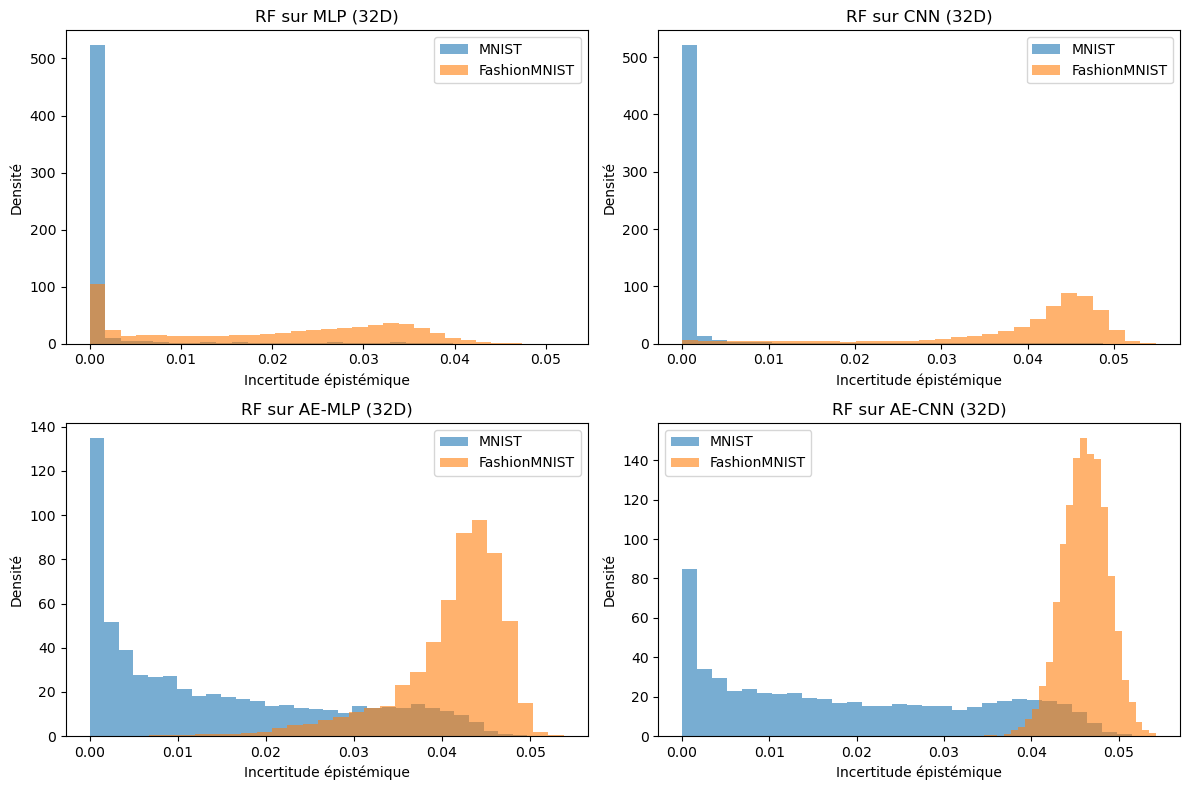

In [15]:
ep_mlp_mnist_test, _, _ = randomForest(X_mlp_train, y_train, X_mlp_mnist_test)
ep_mlp_fashion_test, _, _ = randomForest(X_mlp_train, y_train, X_mlp_fashion_test)

ep_cnn_mnist_test, _, _ = randomForest(X_cnn_train, y_train, X_cnn_mnist_test)
ep_cnn_fashion_test, _, _ = randomForest(X_cnn_train, y_train, X_cnn_fashion_test)

ep_ae_mlp_mnist_test, _, _ = randomForest(X_ae_mlp_train, y_train, X_ae_mlp_mnist_test)
ep_ae_mlp_fashion_test, _, _ = randomForest(X_ae_mlp_train, y_train, X_ae_mlp_fashion_test)

ep_ae_cnn_mnist_test, _, _ = randomForest(X_ae_cnn_train, y_train, X_ae_cnn_mnist_test)
ep_ae_cnn_fashion_test, _, _ = randomForest(X_ae_cnn_train, y_train, X_ae_cnn_fashion_test)

# Graphes de densité (MNIST test vs Fashion test complets)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_mnist_test, ep_mlp_fashion_test, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_mnist_test, ep_cnn_fashion_test, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_mnist_test, ep_ae_mlp_fashion_test, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_mnist_test, ep_ae_cnn_fashion_test, "RF sur AE-CNN (32D)")
]

for ax, ep_mnist, ep_fashion, title in plots:
    ax.hist(ep_mnist, bins=30, density=True, alpha=0.6, label="MNIST")
    ax.hist(ep_fashion, bins=30, density=True, alpha=0.6, label="FashionMNIST")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

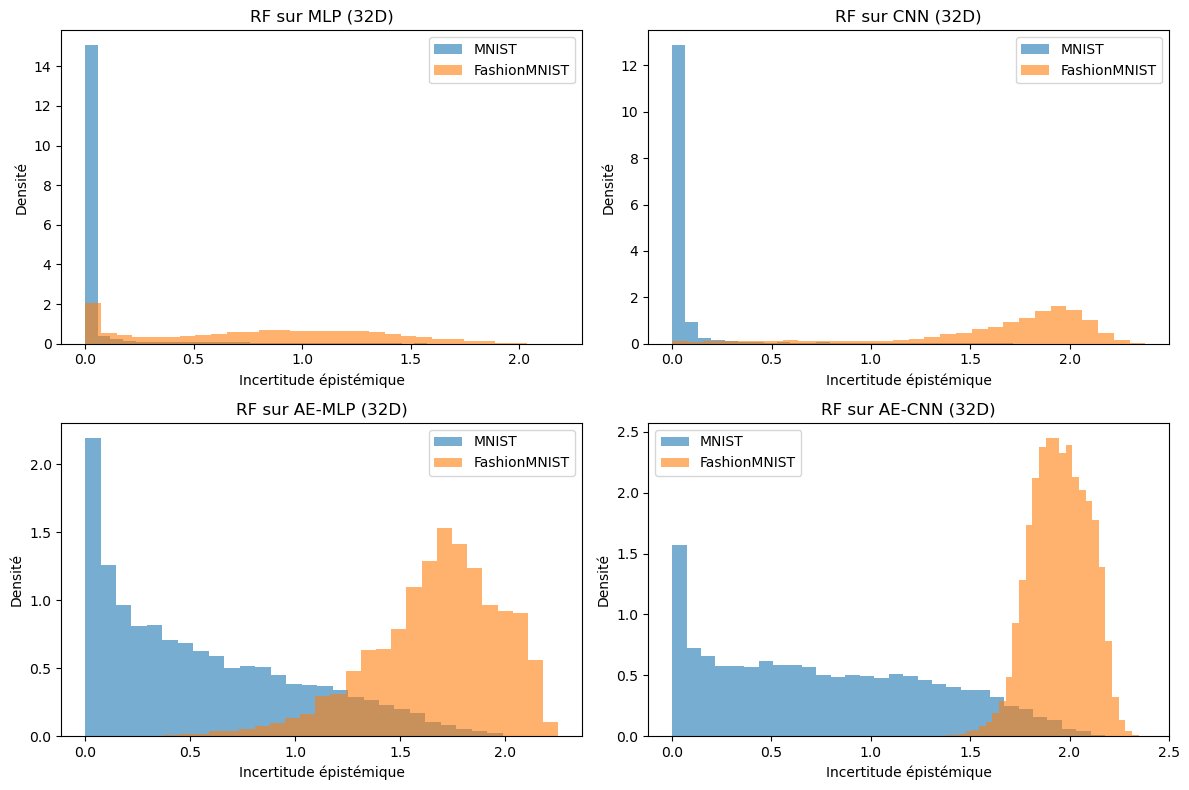

In [16]:
ep_mlp_mnist_test, _, _ = randomForest_entropy(X_mlp_train, y_train, X_mlp_mnist_test)
ep_mlp_fashion_test, _, _ = randomForest_entropy(X_mlp_train, y_train, X_mlp_fashion_test)

ep_cnn_mnist_test, _, _ = randomForest_entropy(X_cnn_train, y_train, X_cnn_mnist_test)
ep_cnn_fashion_test, _, _ = randomForest_entropy(X_cnn_train, y_train, X_cnn_fashion_test)

ep_ae_mlp_mnist_test, _, _ = randomForest_entropy(X_ae_mlp_train, y_train, X_ae_mlp_mnist_test)
ep_ae_mlp_fashion_test, _, _ = randomForest_entropy(X_ae_mlp_train, y_train, X_ae_mlp_fashion_test)

ep_ae_cnn_mnist_test, _, _ = randomForest_entropy(X_ae_cnn_train, y_train, X_ae_cnn_mnist_test)
ep_ae_cnn_fashion_test, _, _ = randomForest_entropy(X_ae_cnn_train, y_train, X_ae_cnn_fashion_test)

# Graphes de densité (MNIST test vs Fashion test complets)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_mnist_test, ep_mlp_fashion_test, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_mnist_test, ep_cnn_fashion_test, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_mnist_test, ep_ae_mlp_fashion_test, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_mnist_test, ep_ae_cnn_fashion_test, "RF sur AE-CNN (32D)")
]

for ax, ep_mnist, ep_fashion, title in plots:
    ax.hist(ep_mnist, bins=30, density=True, alpha=0.6, label="MNIST")
    ax.hist(ep_fashion, bins=30, density=True, alpha=0.6, label="FashionMNIST")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

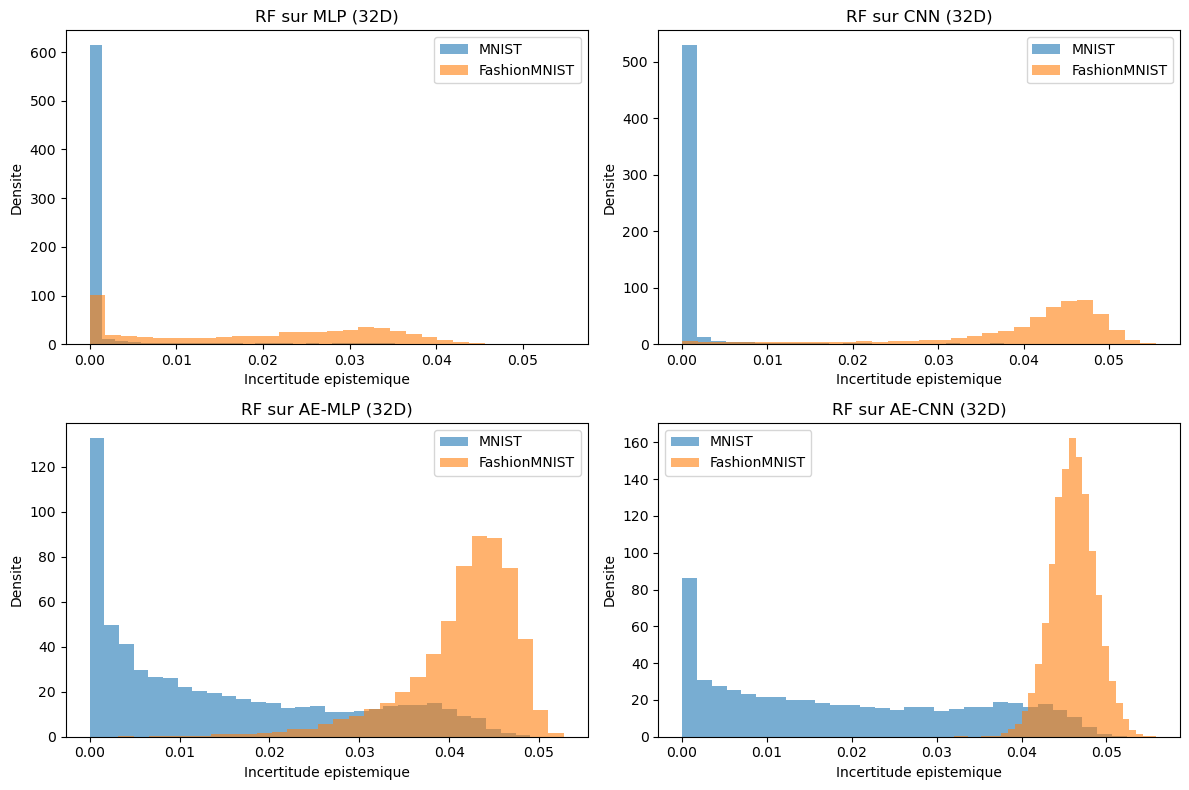

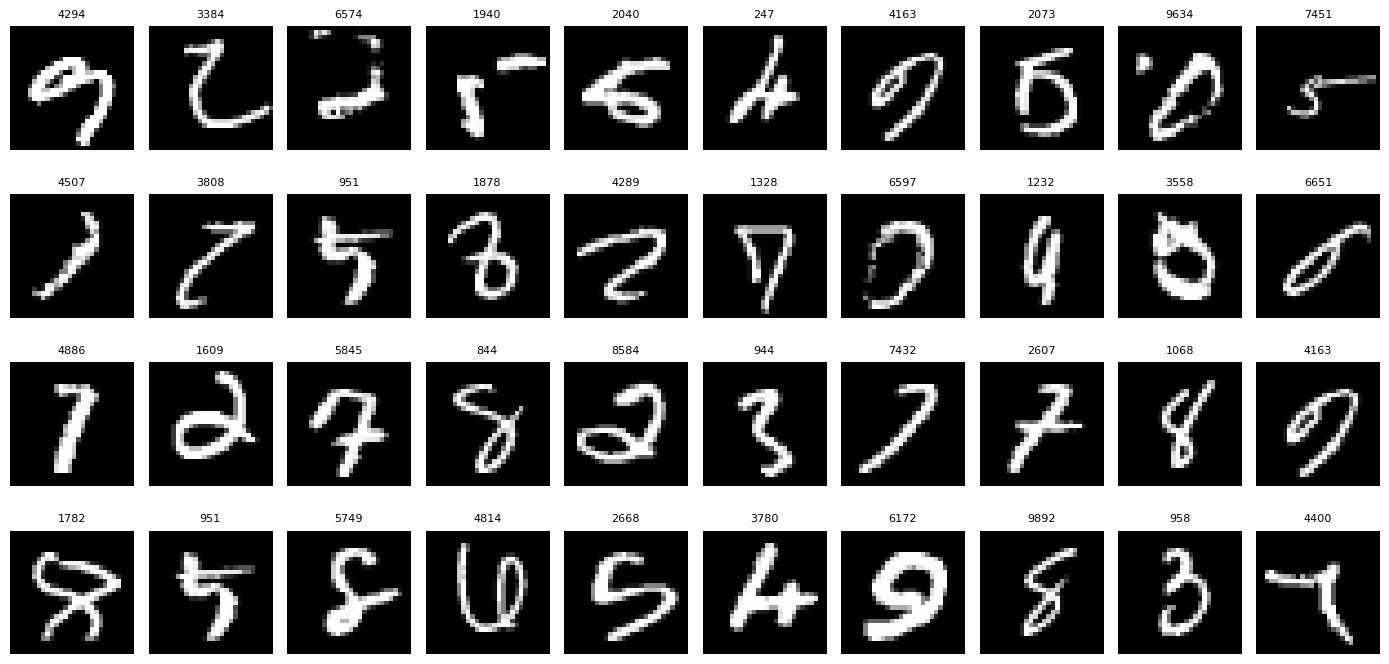

In [17]:
# Random Forest sur representations 32D + incertitude epistemique (MNIST test vs Fashion test complets)

# Donnees d'entrainement (MNIST train en 32D depuis fichiers)
X_mlp_train = mnist_train_mlp_32.tensors[0].numpy()
X_cnn_train = mnist_train_cnn_32.tensors[0].numpy()
X_ae_mlp_train = mnist_train_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = mnist_train_ae_cnn_32.tensors[0].numpy()
y_train = mnist_train_mlp_32.tensors[1].numpy()

# Donnees de test (MNIST test complet en 32D depuis fichiers)
X_mlp_mnist_test = mnist_test_mlp_32.tensors[0].numpy()
X_cnn_mnist_test = mnist_test_cnn_32.tensors[0].numpy()
X_ae_mlp_mnist_test = mnist_test_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_mnist_test = mnist_test_ae_cnn_32.tensors[0].numpy()

# Donnees Fashion MNIST test complet en 32D depuis fichiers
X_mlp_fashion_test = fashion_mlp_32.tensors[0].numpy()
X_cnn_fashion_test = fashion_cnn_32.tensors[0].numpy()
X_ae_mlp_fashion_test = fashion_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_fashion_test = fashion_ae_cnn_32.tensors[0].numpy()

# Entrainer 4 Random Forest
rf_mlp = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_cnn = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_ae_mlp = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_ae_cnn = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=0)

rf_mlp.fit(X_mlp_train, y_train)
rf_cnn.fit(X_cnn_train, y_train)
rf_ae_mlp.fit(X_ae_mlp_train, y_train)
rf_ae_cnn.fit(X_ae_cnn_train, y_train)

# Incertitude epistemique via variance inter-arbres (moyenne sur classes)
def rf_epistemic(rf, X_test):
    p_pred = np.array([tree.predict_proba(X_test) for tree in rf.estimators_])
    ep = np.var(p_pred, axis=0).mean(axis=1)
    return ep

ep_mlp_mnist = rf_epistemic(rf_mlp, X_mlp_mnist_test)
ep_mlp_fashion = rf_epistemic(rf_mlp, X_mlp_fashion_test)

ep_cnn_mnist = rf_epistemic(rf_cnn, X_cnn_mnist_test)
ep_cnn_fashion = rf_epistemic(rf_cnn, X_cnn_fashion_test)

ep_ae_mlp_mnist = rf_epistemic(rf_ae_mlp, X_ae_mlp_mnist_test)
ep_ae_mlp_fashion = rf_epistemic(rf_ae_mlp, X_ae_mlp_fashion_test)

ep_ae_cnn_mnist = rf_epistemic(rf_ae_cnn, X_ae_cnn_mnist_test)
ep_ae_cnn_fashion = rf_epistemic(rf_ae_cnn, X_ae_cnn_fashion_test)

# Graphes de densite (MNIST test vs Fashion test complets)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_mnist, ep_mlp_fashion, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_mnist, ep_cnn_fashion, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_mnist, ep_ae_mlp_fashion, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_mnist, ep_ae_cnn_fashion, "RF sur AE-CNN (32D)"),
]

for ax, ep_mnist, ep_fashion, title in plots:
    ax.hist(ep_mnist, bins=30, density=True, alpha=0.6, label="MNIST")
    ax.hist(ep_fashion, bins=30, density=True, alpha=0.6, label="FashionMNIST")
    ax.set_title(title)
    ax.set_xlabel("Incertitude epistemique")
    ax.set_ylabel("Densite")
    ax.legend()

plt.tight_layout()
plt.show()

# Top 10 MNIST test images with highest epistemic uncertainty for each RF
def topk_idx(ep, k=10):
    return np.argsort(ep)[-k:][::-1]

method_names = ["MLP", "CNN", "AE-MLP", "AE-CNN"]
method_eps = [ep_mlp_mnist, ep_cnn_mnist, ep_ae_mlp_mnist, ep_ae_cnn_mnist]

fig, axes = plt.subplots(4, 10, figsize=(14, 7))
for row, (name, ep) in enumerate(zip(method_names, method_eps)):
    idx_top = topk_idx(ep, k=10)
    for col, idx in enumerate(idx_top):
        ax = axes[row, col]
        img = mnist_test.data[idx]
        if hasattr(img, "numpy"):
            img = img.numpy()
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(str(idx), fontsize=8)
    axes[row, 0].set_ylabel(name, rotation=0, labelpad=35, fontsize=9, va="center")

plt.tight_layout()
plt.show()

# Demo on Cat-Dog-Bird

## Loading the dataset

Telechargement via kagglehub.


Loading Cats+Dogs:   0%|          | 0/10 [00:00<?, ?it/s]

Loading Birds (OOD):   0%|          | 0/10 [00:00<?, ?it/s]

Classes detectees: {'bird': 0, 'cat': 1, 'dog': 2}
Cats: 4015 | Dogs: 5180 | Birds (OOD): 4149
Examples of Cats+Dogs and Bird images:


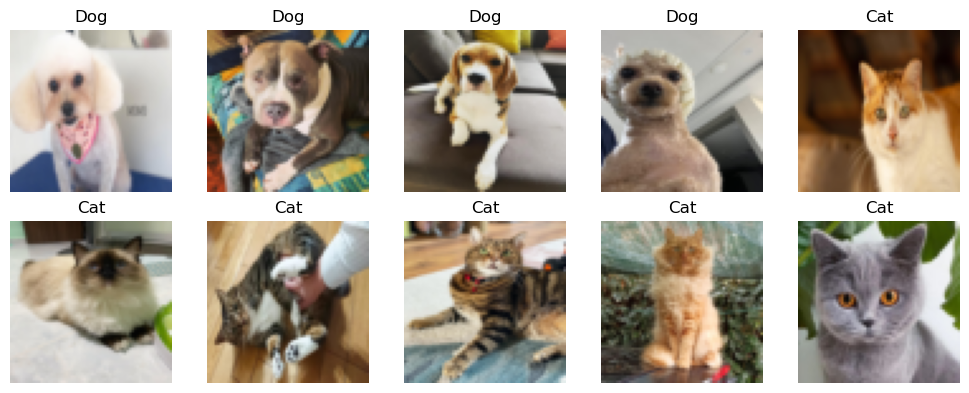

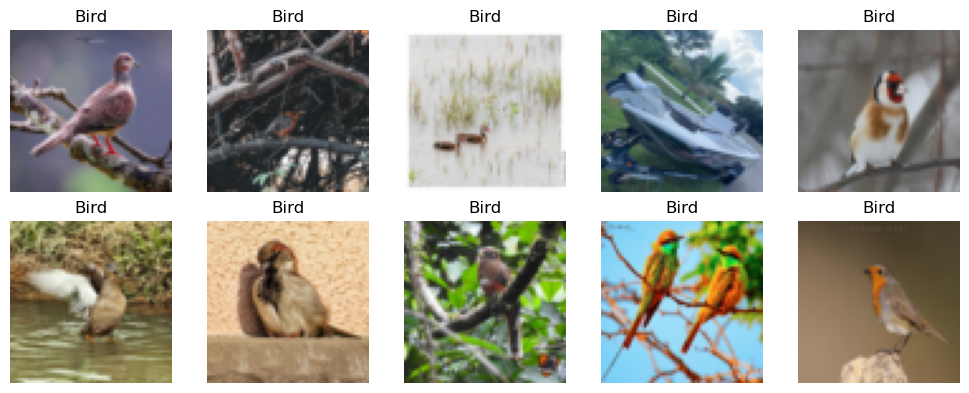

In [18]:
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
import importlib
import zipfile
import glob
import sys
import subprocess

data_root = "./dataset"
batch_size = 128

transform_cdb = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

_rgb_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_rgb_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def to_rgb_image(x):
    x = (x * _rgb_std) + _rgb_mean
    x = x.clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    return x

kaggle_slug = "mahmoudnoor/high-resolution-catdogbird-image-dataset-13000"
local_candidates = [
    os.path.join(data_root, "high-resolution-catdogbird-image-dataset-13000"),
    os.path.join(data_root, "catdogbird"),
    os.path.join(data_root, "cat_dog_bird"),
    os.path.join(data_root, "high-resolution-catdogbird-image-dataset-13000", "Cat Dog Bird"),
]

def locate_imagefolder_root(base_path):
    for current, dirs, _ in os.walk(base_path):
        names = [d.lower() for d in dirs]
        has_cat = any("cat" in n for n in names)
        has_dog = any("dog" in n for n in names)
        has_bird = any("bird" in n for n in names)
        if has_cat and has_dog and has_bird:
            return current
    return None

def ensure_module(module_name, pip_name=None):
    try:
        return importlib.import_module(module_name)
    except Exception:
        pkg = pip_name if pip_name is not None else module_name
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
        return importlib.import_module(module_name)

def download_with_kaggle_api(slug, target_dir):
    kaggle_pkg = ensure_module("kaggle")
    api = kaggle_pkg.api
    os.makedirs(target_dir, exist_ok=True)
    api.dataset_download_files(slug, path=target_dir, unzip=False, quiet=False)

    zip_files = sorted(glob.glob(os.path.join(target_dir, "*.zip")), key=os.path.getmtime, reverse=True)
    if not zip_files:
        raise RuntimeError("Aucun fichier zip telecharge via l'API Kaggle.")
    zip_path = zip_files[0]

    extract_dir = os.path.join(target_dir, "high-resolution-catdogbird-image-dataset-13000")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    return extract_dir

dataset_path = None
for candidate in local_candidates:
    if os.path.exists(candidate):
        dataset_path = candidate
        break

if dataset_path is None:
    try:
        kagglehub = ensure_module("kagglehub")
        dataset_path = kagglehub.dataset_download(kaggle_slug)
        print("Telechargement via kagglehub.")
    except Exception as kagglehub_err:
        try:
            dataset_path = download_with_kaggle_api(kaggle_slug, data_root)
            print("kagglehub indisponible, fallback via package Python kaggle.")
        except Exception as kaggle_err:
            raise RuntimeError(
                "Impossible de telecharger le dataset. "
                f"kagglehub: {kagglehub_err} | kaggle(api): {kaggle_err}"
            )

imagefolder_root = locate_imagefolder_root(dataset_path)
if imagefolder_root is None:
    raise RuntimeError(
        "Racine ImageFolder introuvable (classes cat/dog/bird). "
        f"Verifie le contenu de: {dataset_path}"
    )

full_cdb = ImageFolder(root=imagefolder_root, transform=transform_cdb)
class_to_idx = {k.lower(): v for k, v in full_cdb.class_to_idx.items()}

cat_idx = next((v for k, v in class_to_idx.items() if "cat" in k), None)
dog_idx = next((v for k, v in class_to_idx.items() if "dog" in k), None)
bird_idx = next((v for k, v in class_to_idx.items() if "bird" in k), None)

if cat_idx is None or dog_idx is None or bird_idx is None:
    raise RuntimeError(f"Classes detectees: {full_cdb.class_to_idx} (cat/dog/bird requis)")

cat_indices, dog_indices, bird_indices = [], [], []
for sample_idx, (_, label) in enumerate(full_cdb.samples):
    if label == cat_idx:
        cat_indices.append(sample_idx)
    elif label == dog_idx:
        dog_indices.append(sample_idx)
    elif label == bird_idx:
        bird_indices.append(sample_idx)

catdog_indices = cat_indices + dog_indices

cat_dataset = Subset(full_cdb, cat_indices)
dog_dataset = Subset(full_cdb, dog_indices)
bird_dataset = Subset(full_cdb, bird_indices)
catdog_dataset = Subset(full_cdb, catdog_indices)

catdog_loader = DataLoader(catdog_dataset, batch_size=batch_size, shuffle=True)
catdog_eval_loader = DataLoader(catdog_dataset, batch_size=batch_size, shuffle=False)
cat_loader = DataLoader(cat_dataset, batch_size=batch_size, shuffle=False)
dog_loader = DataLoader(dog_dataset, batch_size=batch_size, shuffle=False)
bird_loader = DataLoader(bird_dataset, batch_size=batch_size, shuffle=False)

for _ in tqdm(islice(catdog_loader, 10), total=10, desc="Loading Cats+Dogs"):
    pass
for _ in tqdm(islice(bird_loader, 10), total=10, desc="Loading Birds (OOD)"):
    pass

print(f"Classes detectees: {full_cdb.class_to_idx}")
print(f"Cats: {len(cat_dataset)} | Dogs: {len(dog_dataset)} | Birds (OOD): {len(bird_dataset)}")
print("Examples of Cats+Dogs and Bird images:")

rng = np.random.default_rng(0)
idx_catdog = rng.choice(len(catdog_dataset), size=min(10, len(catdog_dataset)), replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()
for ax, idx in zip(axes, idx_catdog):
    img, label = catdog_dataset[idx]
    ax.imshow(to_rgb_image(img))
    ax.set_title("Cat" if label == cat_idx else "Dog")
    ax.axis("off")
for ax in axes[len(idx_catdog):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

idx_bird = rng.choice(len(bird_dataset), size=min(10, len(bird_dataset)), replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()
for ax, idx in zip(axes, idx_bird):
    img, _ = bird_dataset[idx]
    ax.imshow(to_rgb_image(img))
    ax.set_title("Bird")
    ax.axis("off")
for ax in axes[len(idx_bird):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Training our models

### Supervised Learning : Multi-Layer Perceptron

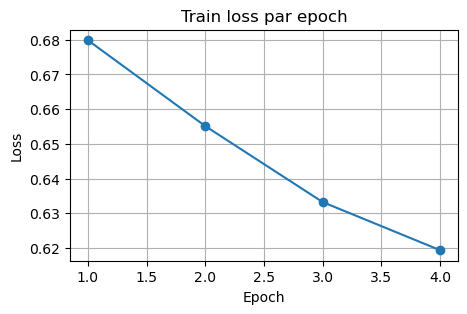

MLP_CDB(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLP_CDB(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64 * 3, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

mlp_cdb = MLP_CDB().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_cdb.parameters(), lr=1e-3)

epochs = 4
train_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    mlp_cdb.train()
    running_loss = 0.0
    for x, y in tqdm(catdog_loader, desc=f"Epoch {epoch}"):
        x = x.to(device)
        y = y.to(device)
        y_bin = (y == dog_idx).long()

        optimizer.zero_grad()
        logits = mlp_cdb(x)
        loss = criterion(logits, y_bin)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(catdog_loader.dataset)
    train_losses.append(train_loss)
    print(f"Epoch {epoch} - loss: {train_loss:.4f}")

    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
    ax.set_title("Train loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(mlp_cdb)

### Supervised Learning : Convolutional Neural Network

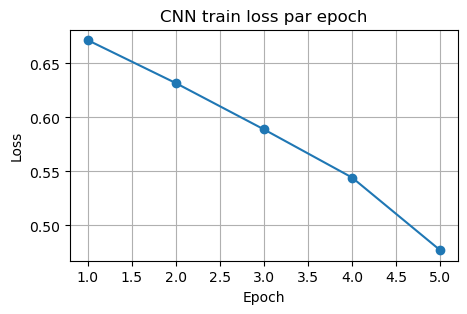

CNN_CDB(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class CNN_CDB(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_cdb = CNN_CDB().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_cdb.parameters(), lr=1e-3)

epochs = 5
train_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    cnn_cdb.train()
    running_loss = 0.0
    for x, y in tqdm(catdog_loader, desc=f"CNN Epoch {epoch}"):
        x = x.to(device)
        y = y.to(device)
        y_bin = (y == dog_idx).long()

        optimizer.zero_grad()
        logits = cnn_cdb(x)
        loss = criterion(logits, y_bin)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(catdog_loader.dataset)
    train_losses.append(train_loss)
    print(f"CNN Epoch {epoch} - loss: {train_loss:.4f}")

    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
    ax.set_title("CNN train loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(cnn_cdb)

### Unsupervised Learning : MLP Auto-Encoder

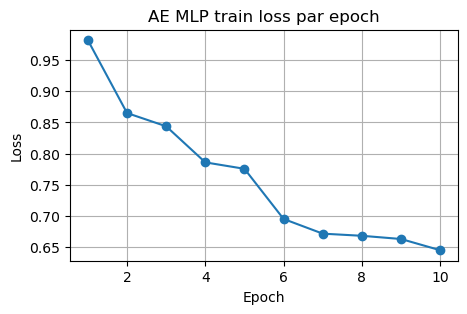

AE_MLP_CDB(
  (encoder): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=12288, bias=True)
  )
)


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_MLP_CDB(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(64 * 64 * 3, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 64 * 64 * 3)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

ae_mlp_cdb = AE_MLP_CDB().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_mlp_cdb.parameters(), lr=1e-3)

epochs = 10
train_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_mlp_cdb.train()
    running_loss = 0.0
    for x, _ in tqdm(catdog_loader, desc=f"AE Epoch {epoch}"):
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        optimizer.zero_grad()
        recon = ae_mlp_cdb(x_flat)
        loss = criterion(recon, x_flat)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(catdog_loader.dataset)
    train_losses.append(train_loss)
    print(f"AE Epoch {epoch} - loss: {train_loss:.4f}")

    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
    ax.set_title("AE MLP train loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_mlp_cdb)

### Unsupervised Learning : CNN Auto-Encoder

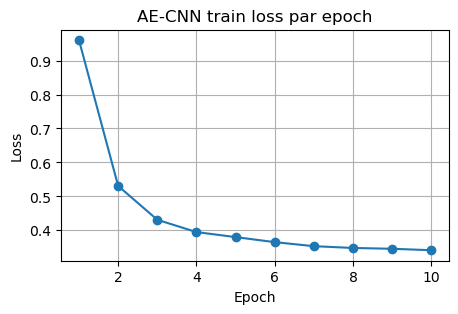

AE_CNN_CDB(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=32, bias=True)
  )
  (unbottleneck): Sequential(
    (0): Linear(in_features=32, out_features=32768, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AE_CNN_CDB(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.bottleneck = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 32)
        )
        self.unbottleneck = nn.Sequential(
            nn.Linear(32, 128 * 16 * 16),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 3, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        z = self.bottleneck(x)
        x = self.unbottleneck(z).view(-1, 128, 16, 16)
        x = self.decoder(x)
        return x

ae_cnn_cdb = AE_CNN_CDB().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_cnn_cdb.parameters(), lr=1e-3)

epochs = 10
train_losses = []

fig, ax = plt.subplots(figsize=(5, 3))
for epoch in range(1, epochs + 1):
    ae_cnn_cdb.train()
    running_loss = 0.0
    for x, _ in tqdm(catdog_loader, desc=f"AE-CNN Epoch {epoch}"):
        x = x.to(device)
        optimizer.zero_grad()
        recon = ae_cnn_cdb(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(catdog_loader.dataset)
    train_losses.append(train_loss)
    print(f"AE-CNN Epoch {epoch} - loss: {train_loss:.4f}")

    clear_output(wait=True)
    ax.cla()
    ax.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
    ax.set_title("AE-CNN train loss par epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    display(fig)

plt.close(fig)
print(ae_cnn_cdb)

### Model performance comparaison

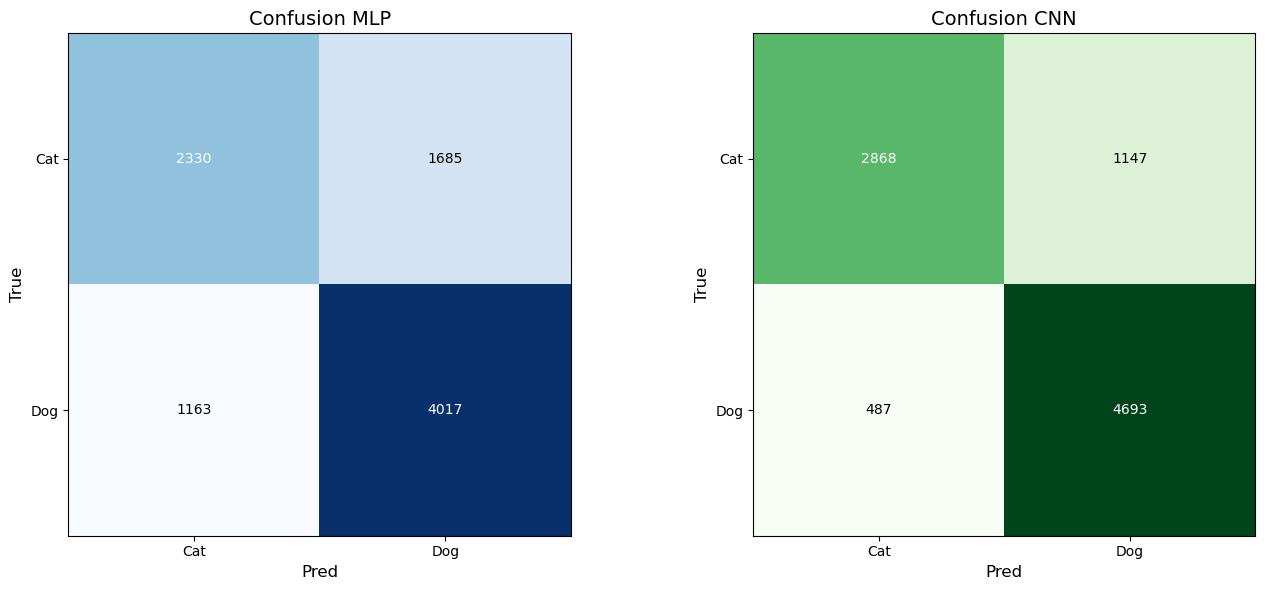

,model,accuracy,precision_macro,recall_macro,f1_macro
0,MLP,0.690266,0.685769,0.677903,0.679477
1,CNN,0.822295,0.829220,0.810153,0.815007


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_cdb.eval()
cnn_cdb.eval()

y_true = []
y_pred_mlp = []
y_pred_cnn = []

with torch.no_grad():
    for x, y in catdog_eval_loader:
        x = x.to(device)
        y_bin = (y == dog_idx).long().numpy().tolist()
        logits_mlp = mlp_cdb(x)
        logits_cnn = cnn_cdb(x)
        y_true.extend(y_bin)
        y_pred_mlp.extend(logits_mlp.argmax(dim=1).cpu().numpy().tolist())
        y_pred_cnn.extend(logits_cnn.argmax(dim=1).cpu().numpy().tolist())

cm_mlp = confusion_matrix(y_true, y_pred_mlp)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cm_mlp, cmap="Blues")
axes[0].set_title("Confusion MLP", fontsize=14)
axes[0].set_xlabel("Pred", fontsize=12)
axes[0].set_ylabel("True", fontsize=12)
axes[1].imshow(cm_cnn, cmap="Greens")
axes[1].set_title("Confusion CNN", fontsize=14)
axes[1].set_xlabel("Pred", fontsize=12)
axes[1].set_ylabel("True", fontsize=12)

for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        axes[0].text(j, i, cm_mlp[i, j], ha="center", va="center", fontsize=10,
                     color="white" if cm_mlp[i, j] > cm_mlp.max() / 2 else "black")
for i in range(cm_cnn.shape[0]):
    for j in range(cm_cnn.shape[1]):
        axes[1].text(j, i, cm_cnn[i, j], ha="center", va="center", fontsize=10,
                     color="white" if cm_cnn[i, j] > cm_cnn.max() / 2 else "black")

axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Cat", "Dog"]); axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Cat", "Dog"])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Cat", "Dog"]); axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["Cat", "Dog"])

plt.tight_layout()
plt.show()

metrics = pd.DataFrame([
    {
        "model": "MLP",
        "accuracy": accuracy_score(y_true, y_pred_mlp),
        "precision_macro": precision_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_mlp, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_mlp, average="macro", zero_division=0),
    },
    {
        "model": "CNN",
        "accuracy": accuracy_score(y_true, y_pred_cnn),
        "precision_macro": precision_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred_cnn, average="macro", zero_division=0),
    }
])

metrics

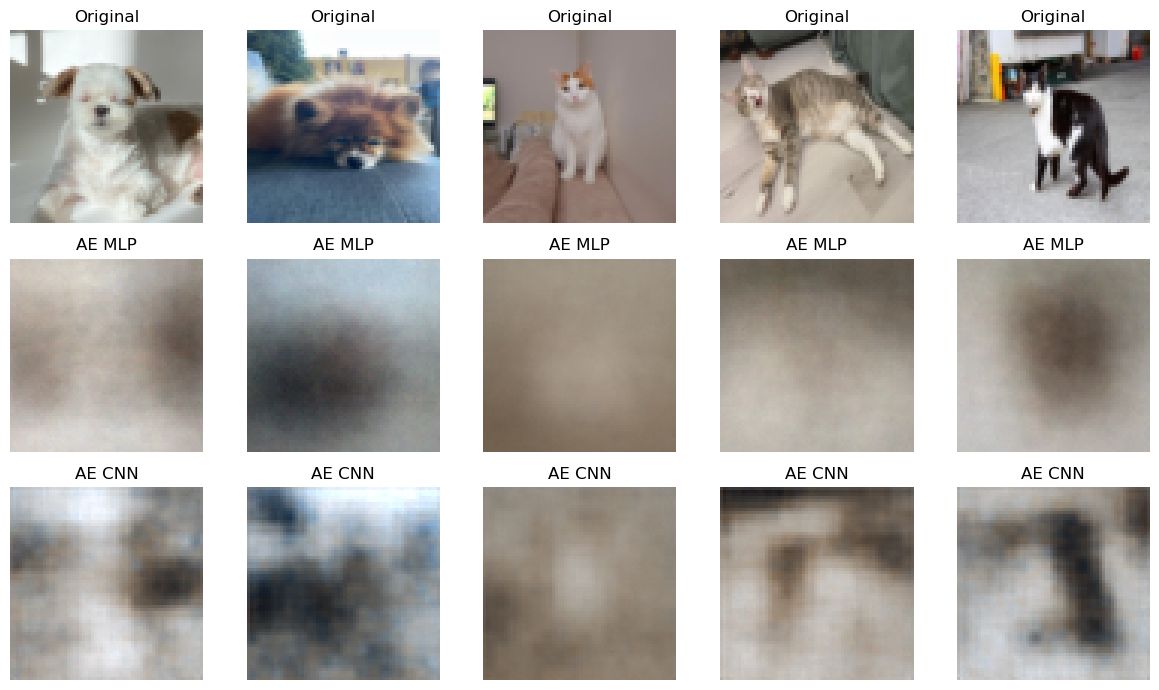

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ae_mlp_cdb.eval()
ae_cnn_cdb.eval()

_rgb_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_rgb_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def to_rgb_image(x):
    x = (x * _rgb_std) + _rgb_mean
    x = x.clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    return x

idx = np.random.choice(len(catdog_dataset), size=min(5, len(catdog_dataset)), replace=False)
images = torch.stack([catdog_dataset[i][0] for i in idx]).to(device)

with torch.no_grad():
    recon_mlp = ae_mlp_cdb(images.view(images.size(0), -1)).view(-1, 3, 64, 64)
    recon_cnn = ae_cnn_cdb(images)

images = images.cpu()
recon_mlp = recon_mlp.cpu()
recon_cnn = recon_cnn.cpu()

fig, axes = plt.subplots(3, min(5, len(idx)), figsize=(12, 7))
if len(idx) == 1:
    axes = np.array(axes).reshape(3, 1)
for i in range(len(idx)):
    axes[0, i].imshow(to_rgb_image(images[i]))
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(to_rgb_image(recon_mlp[i]))
    axes[1, i].set_title("AE MLP")
    axes[1, i].axis("off")
    axes[2, i].imshow(to_rgb_image(recon_cnn[i]))
    axes[2, i].set_title("AE CNN")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

## Uncertainty Quantification

### Save 32 neurons datasets

In [25]:
device = next(mlp_cdb.parameters()).device

@torch.no_grad()
def extract_mlp_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.net[:-1](x)
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_cnn_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.classifier[:-1](model.features(x))
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_ae_mlp_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)
        f = model.encoder(x_flat)
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

@torch.no_grad()
def extract_ae_cnn_features(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        f = model.bottleneck(model.encoder(x))
        feats.append(f.cpu())
        labels.append(y.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)

In [26]:
X_mlp_train, y_train_raw = extract_mlp_features(mlp_cdb, catdog_eval_loader)
X_cnn_train, y_cnn_train_raw = extract_cnn_features(cnn_cdb, catdog_eval_loader)
X_ae_mlp_train, y_ae_mlp_train_raw = extract_ae_mlp_features(ae_mlp_cdb, catdog_eval_loader)
X_ae_cnn_train, y_ae_cnn_train_raw = extract_ae_cnn_features(ae_cnn_cdb, catdog_eval_loader)

X_mlp_cat, y_cat = extract_mlp_features(mlp_cdb, cat_loader)
X_cnn_cat, y_cnn_cat = extract_cnn_features(cnn_cdb, cat_loader)
X_ae_mlp_cat, y_ae_mlp_cat = extract_ae_mlp_features(ae_mlp_cdb, cat_loader)
X_ae_cnn_cat, y_ae_cnn_cat = extract_ae_cnn_features(ae_cnn_cdb, cat_loader)

X_mlp_dog, y_dog = extract_mlp_features(mlp_cdb, dog_loader)
X_cnn_dog, y_cnn_dog = extract_cnn_features(cnn_cdb, dog_loader)
X_ae_mlp_dog, y_ae_mlp_dog = extract_ae_mlp_features(ae_mlp_cdb, dog_loader)
X_ae_cnn_dog, y_ae_cnn_dog = extract_ae_cnn_features(ae_cnn_cdb, dog_loader)

X_mlp_bird, y_bird = extract_mlp_features(mlp_cdb, bird_loader)
X_cnn_bird, y_cnn_bird = extract_cnn_features(cnn_cdb, bird_loader)
X_ae_mlp_bird, y_ae_mlp_bird = extract_ae_mlp_features(ae_mlp_cdb, bird_loader)
X_ae_cnn_bird, y_ae_cnn_bird = extract_ae_cnn_features(ae_cnn_cdb, bird_loader)

catdog_train_mlp_32 = TensorDataset(X_mlp_train, y_train_raw)
catdog_train_cnn_32 = TensorDataset(X_cnn_train, y_cnn_train_raw)
catdog_train_ae_mlp_32 = TensorDataset(X_ae_mlp_train, y_ae_mlp_train_raw)
catdog_train_ae_cnn_32 = TensorDataset(X_ae_cnn_train, y_ae_cnn_train_raw)

cat_mlp_32 = TensorDataset(X_mlp_cat, y_cat)
cat_cnn_32 = TensorDataset(X_cnn_cat, y_cnn_cat)
cat_ae_mlp_32 = TensorDataset(X_ae_mlp_cat, y_ae_mlp_cat)
cat_ae_cnn_32 = TensorDataset(X_ae_cnn_cat, y_ae_cnn_cat)

dog_mlp_32 = TensorDataset(X_mlp_dog, y_dog)
dog_cnn_32 = TensorDataset(X_cnn_dog, y_cnn_dog)
dog_ae_mlp_32 = TensorDataset(X_ae_mlp_dog, y_ae_mlp_dog)
dog_ae_cnn_32 = TensorDataset(X_ae_cnn_dog, y_ae_cnn_dog)

bird_mlp_32 = TensorDataset(X_mlp_bird, y_bird)
bird_cnn_32 = TensorDataset(X_cnn_bird, y_cnn_bird)
bird_ae_mlp_32 = TensorDataset(X_ae_mlp_bird, y_ae_mlp_bird)
bird_ae_cnn_32 = TensorDataset(X_ae_cnn_bird, y_ae_cnn_bird)

out_dir = os.path.join(data_root, "representations_32_cdb")
os.makedirs(out_dir, exist_ok=True)

torch.save(catdog_train_mlp_32, os.path.join(out_dir, "catdog_train_mlp_32.pt"))
torch.save(catdog_train_cnn_32, os.path.join(out_dir, "catdog_train_cnn_32.pt"))
torch.save(catdog_train_ae_mlp_32, os.path.join(out_dir, "catdog_train_ae_mlp_32.pt"))
torch.save(catdog_train_ae_cnn_32, os.path.join(out_dir, "catdog_train_ae_cnn_32.pt"))

torch.save(cat_mlp_32, os.path.join(out_dir, "cat_mlp_32.pt"))
torch.save(cat_cnn_32, os.path.join(out_dir, "cat_cnn_32.pt"))
torch.save(cat_ae_mlp_32, os.path.join(out_dir, "cat_ae_mlp_32.pt"))
torch.save(cat_ae_cnn_32, os.path.join(out_dir, "cat_ae_cnn_32.pt"))

torch.save(dog_mlp_32, os.path.join(out_dir, "dog_mlp_32.pt"))
torch.save(dog_cnn_32, os.path.join(out_dir, "dog_cnn_32.pt"))
torch.save(dog_ae_mlp_32, os.path.join(out_dir, "dog_ae_mlp_32.pt"))
torch.save(dog_ae_cnn_32, os.path.join(out_dir, "dog_ae_cnn_32.pt"))

torch.save(bird_mlp_32, os.path.join(out_dir, "bird_mlp_32.pt"))
torch.save(bird_cnn_32, os.path.join(out_dir, "bird_cnn_32.pt"))
torch.save(bird_ae_mlp_32, os.path.join(out_dir, "bird_ae_mlp_32.pt"))
torch.save(bird_ae_cnn_32, os.path.join(out_dir, "bird_ae_cnn_32.pt"))

print("Sauvegarde OK:", out_dir)

Sauvegarde OK: ./dataset\representations_32_cdb


### Random forest

In [27]:
rep_dir = os.path.join(data_root, "representations_32_cdb")

catdog_train_mlp_32 = torch.load(os.path.join(rep_dir, "catdog_train_mlp_32.pt"))
catdog_train_cnn_32 = torch.load(os.path.join(rep_dir, "catdog_train_cnn_32.pt"))
catdog_train_ae_mlp_32 = torch.load(os.path.join(rep_dir, "catdog_train_ae_mlp_32.pt"))
catdog_train_ae_cnn_32 = torch.load(os.path.join(rep_dir, "catdog_train_ae_cnn_32.pt"))

bird_mlp_32 = torch.load(os.path.join(rep_dir, "bird_mlp_32.pt"))
bird_cnn_32 = torch.load(os.path.join(rep_dir, "bird_cnn_32.pt"))
bird_ae_mlp_32 = torch.load(os.path.join(rep_dir, "bird_ae_mlp_32.pt"))
bird_ae_cnn_32 = torch.load(os.path.join(rep_dir, "bird_ae_cnn_32.pt"))

X_mlp_train = catdog_train_mlp_32.tensors[0].numpy()
X_cnn_train = catdog_train_cnn_32.tensors[0].numpy()
X_ae_mlp_train = catdog_train_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = catdog_train_ae_cnn_32.tensors[0].numpy()
y_train_raw = catdog_train_mlp_32.tensors[1].numpy()
y_train = (y_train_raw == dog_idx).astype(np.int64)

X_mlp_bird = bird_mlp_32.tensors[0].numpy()
X_cnn_bird = bird_cnn_32.tensors[0].numpy()
X_ae_mlp_bird = bird_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_bird = bird_ae_cnn_32.tensors[0].numpy()

def randomForest(X, y, X_test, nb_estimators=200):
    model = RandomForestClassifier(n_estimators=nb_estimators, min_samples_leaf=5)
    model.fit(X, y)
    preds = np.array(model.predict_proba(X_test))

    unc_tree = []
    p_pred = []
    for tree in model.estimators_:
        pred_t = tree.predict_proba(X_test)
        p_pred.append(pred_t)
        unc_tree.append(-np.sum(pred_t * np.log2(pred_t + 1e-10), axis=1))
    p_pred = np.array(p_pred)
    ep = np.var(p_pred[:, :, 0], axis=0)
    return ep, p_pred, preds

def randomForest_entropy(X, y, X_test, nb_estimators=200):
    model = RandomForestClassifier(n_estimators=nb_estimators, min_samples_leaf=5)
    model.fit(X, y)
    preds = np.array(model.predict_proba(X_test))

    unc_tree = []
    p_pred = []
    for tree in model.estimators_:
        pred_t = tree.predict_proba(X_test)
        p_pred.append(pred_t)
        unc_tree.append(-np.sum(pred_t * np.log2(pred_t + 1e-10), axis=1))

    entropy_per_tree = np.array(unc_tree)
    mean_entropy = np.mean(entropy_per_tree, axis=0)
    pred_mean = np.mean(p_pred, axis=0)
    entropy_of_mean = -np.sum(pred_mean * np.log2(pred_mean + 1e-10), axis=1)
    ep = entropy_of_mean - mean_entropy
    return ep, p_pred, preds

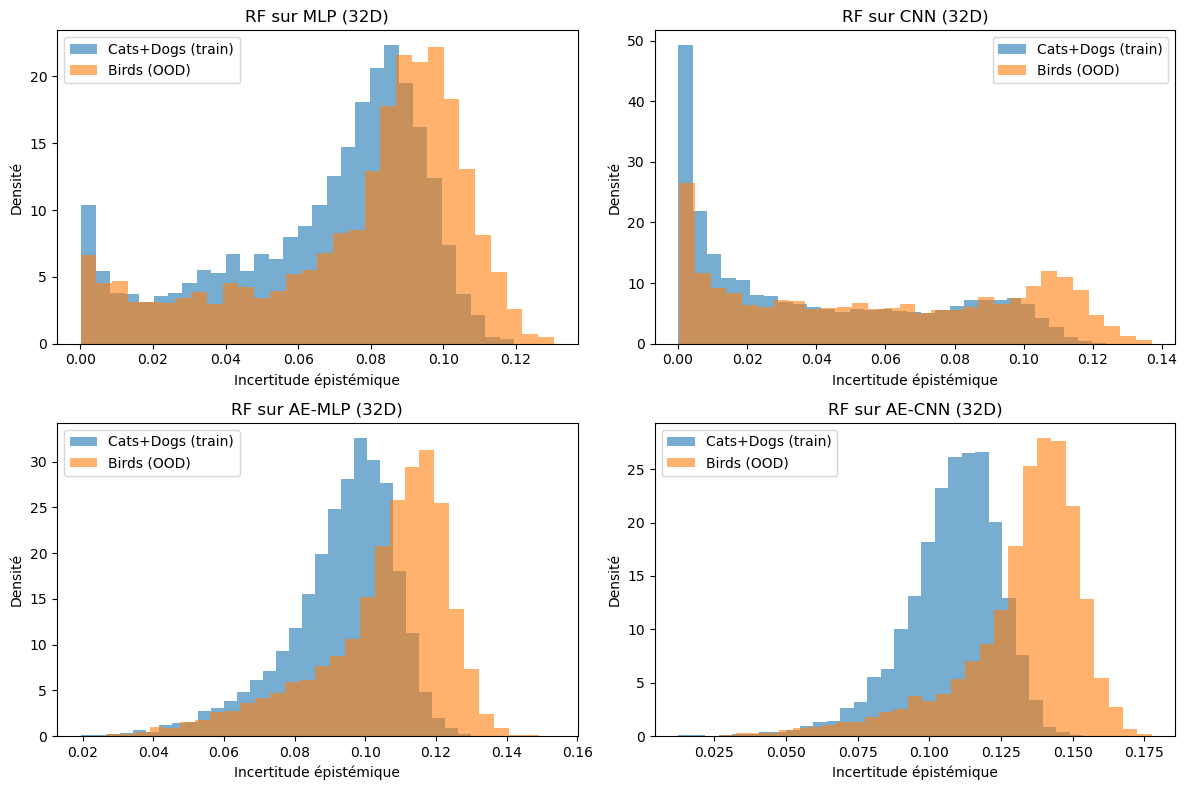

In [28]:
ep_mlp_train, _, _ = randomForest(X_mlp_train, y_train, X_mlp_train)
ep_mlp_bird, _, _ = randomForest(X_mlp_train, y_train, X_mlp_bird)

ep_cnn_train, _, _ = randomForest(X_cnn_train, y_train, X_cnn_train)
ep_cnn_bird, _, _ = randomForest(X_cnn_train, y_train, X_cnn_bird)

ep_ae_mlp_train, _, _ = randomForest(X_ae_mlp_train, y_train, X_ae_mlp_train)
ep_ae_mlp_bird, _, _ = randomForest(X_ae_mlp_train, y_train, X_ae_mlp_bird)

ep_ae_cnn_train, _, _ = randomForest(X_ae_cnn_train, y_train, X_ae_cnn_train)
ep_ae_cnn_bird, _, _ = randomForest(X_ae_cnn_train, y_train, X_ae_cnn_bird)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_train, ep_mlp_bird, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_train, ep_cnn_bird, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_train, ep_ae_mlp_bird, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_train, ep_ae_cnn_bird, "RF sur AE-CNN (32D)")
]

for ax, ep_id, ep_ood, title in plots:
    ax.hist(ep_id, bins=30, density=True, alpha=0.6, label="Cats+Dogs (train)")
    ax.hist(ep_ood, bins=30, density=True, alpha=0.6, label="Birds (OOD)")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

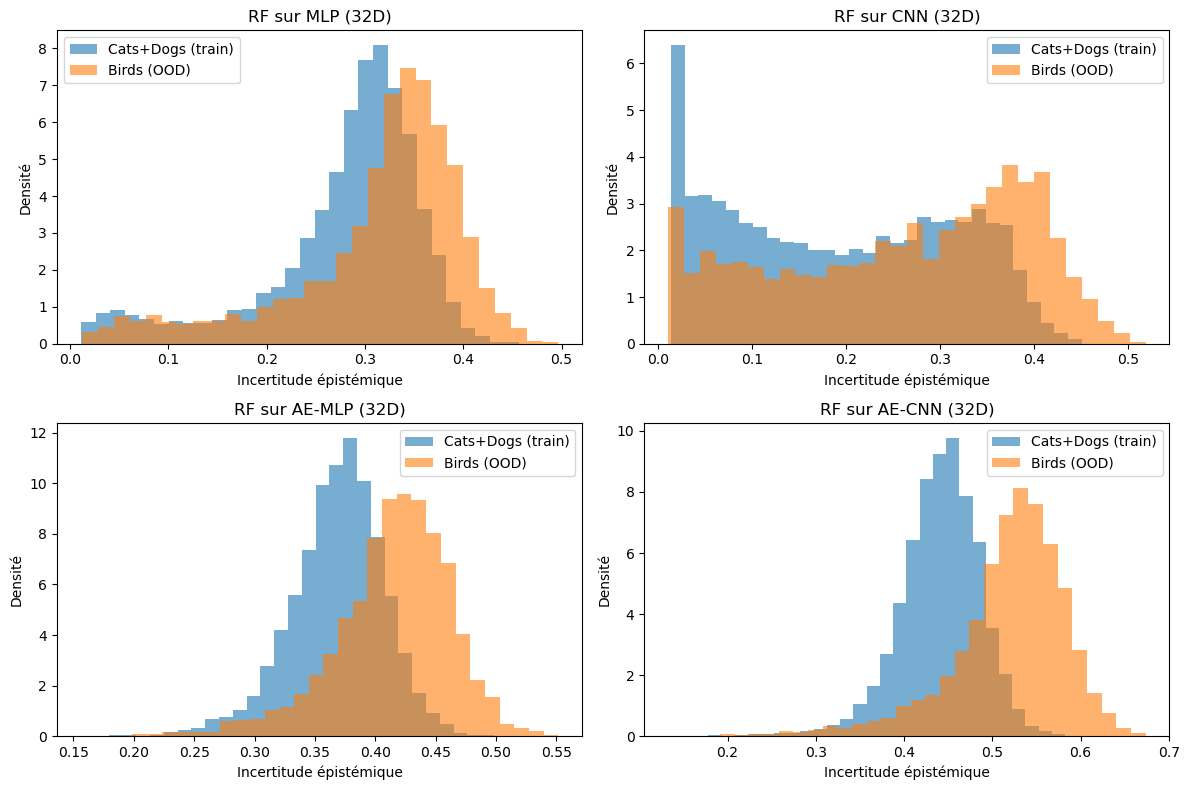

In [29]:
ep_mlp_train, _, _ = randomForest_entropy(X_mlp_train, y_train, X_mlp_train)
ep_mlp_bird, _, _ = randomForest_entropy(X_mlp_train, y_train, X_mlp_bird)

ep_cnn_train, _, _ = randomForest_entropy(X_cnn_train, y_train, X_cnn_train)
ep_cnn_bird, _, _ = randomForest_entropy(X_cnn_train, y_train, X_cnn_bird)

ep_ae_mlp_train, _, _ = randomForest_entropy(X_ae_mlp_train, y_train, X_ae_mlp_train)
ep_ae_mlp_bird, _, _ = randomForest_entropy(X_ae_mlp_train, y_train, X_ae_mlp_bird)

ep_ae_cnn_train, _, _ = randomForest_entropy(X_ae_cnn_train, y_train, X_ae_cnn_train)
ep_ae_cnn_bird, _, _ = randomForest_entropy(X_ae_cnn_train, y_train, X_ae_cnn_bird)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_train, ep_mlp_bird, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_train, ep_cnn_bird, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_train, ep_ae_mlp_bird, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_train, ep_ae_cnn_bird, "RF sur AE-CNN (32D)")
]

for ax, ep_id, ep_ood, title in plots:
    ax.hist(ep_id, bins=30, density=True, alpha=0.6, label="Cats+Dogs (train)")
    ax.hist(ep_ood, bins=30, density=True, alpha=0.6, label="Birds (OOD)")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()

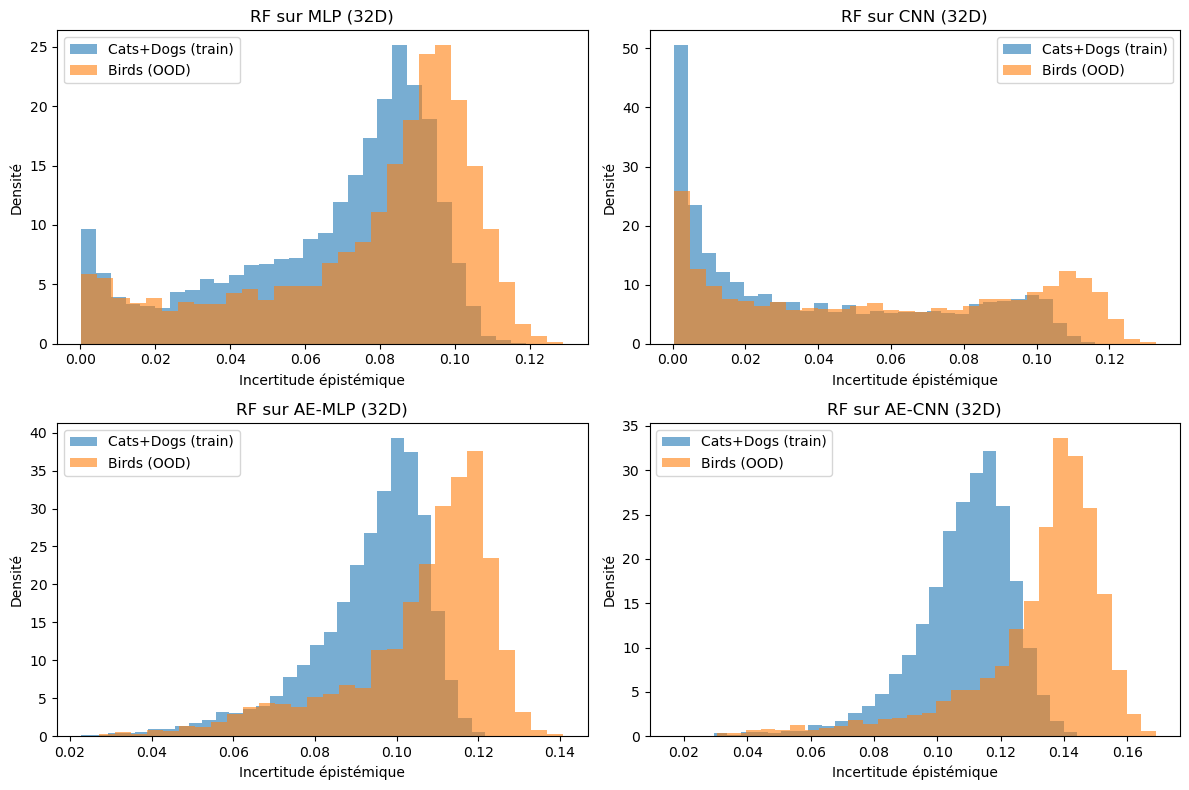

In [30]:
X_mlp_train = catdog_train_mlp_32.tensors[0].numpy()
X_cnn_train = catdog_train_cnn_32.tensors[0].numpy()
X_ae_mlp_train = catdog_train_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_train = catdog_train_ae_cnn_32.tensors[0].numpy()
y_train_raw = catdog_train_mlp_32.tensors[1].numpy()
y_train = (y_train_raw == dog_idx).astype(np.int64)

X_mlp_bird = bird_mlp_32.tensors[0].numpy()
X_cnn_bird = bird_cnn_32.tensors[0].numpy()
X_ae_mlp_bird = bird_ae_mlp_32.tensors[0].numpy()
X_ae_cnn_bird = bird_ae_cnn_32.tensors[0].numpy()

rf_mlp = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_cnn = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_ae_mlp = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf_ae_cnn = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=0)

rf_mlp.fit(X_mlp_train, y_train)
rf_cnn.fit(X_cnn_train, y_train)
rf_ae_mlp.fit(X_ae_mlp_train, y_train)
rf_ae_cnn.fit(X_ae_cnn_train, y_train)

def rf_epistemic(rf, X_test):
    p_pred = np.array([tree.predict_proba(X_test) for tree in rf.estimators_])
    ep = np.var(p_pred, axis=0).mean(axis=1)
    return ep

ep_mlp_train = rf_epistemic(rf_mlp, X_mlp_train)
ep_mlp_bird = rf_epistemic(rf_mlp, X_mlp_bird)

ep_cnn_train = rf_epistemic(rf_cnn, X_cnn_train)
ep_cnn_bird = rf_epistemic(rf_cnn, X_cnn_bird)

ep_ae_mlp_train = rf_epistemic(rf_ae_mlp, X_ae_mlp_train)
ep_ae_mlp_bird = rf_epistemic(rf_ae_mlp, X_ae_mlp_bird)

ep_ae_cnn_train = rf_epistemic(rf_ae_cnn, X_ae_cnn_train)
ep_ae_cnn_bird = rf_epistemic(rf_ae_cnn, X_ae_cnn_bird)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (axes[0, 0], ep_mlp_train, ep_mlp_bird, "RF sur MLP (32D)"),
    (axes[0, 1], ep_cnn_train, ep_cnn_bird, "RF sur CNN (32D)"),
    (axes[1, 0], ep_ae_mlp_train, ep_ae_mlp_bird, "RF sur AE-MLP (32D)"),
    (axes[1, 1], ep_ae_cnn_train, ep_ae_cnn_bird, "RF sur AE-CNN (32D)")
]

for ax, ep_id, ep_ood, title in plots:
    ax.hist(ep_id, bins=30, density=True, alpha=0.6, label="Cats+Dogs (train)")
    ax.hist(ep_ood, bins=30, density=True, alpha=0.6, label="Birds (OOD)")
    ax.set_title(title)
    ax.set_xlabel("Incertitude épistémique")
    ax.set_ylabel("Densité")
    ax.legend()

plt.tight_layout()
plt.show()